In [33]:
%load_ext autoreload
%autoreload 2
import pylupnt as pnt
import pandas as pd
import numpy as np
import pathfinder_data
import matplotlib.pyplot as plt
# %matplotlib widget

import rover
import sympy as sp
import scipy.optimize as opt
import scipy as sc

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
def p_norm_trajectory(x, p, a = 1, b = 1, c = 1):
    """ Generate a p-norm trajectory for given x values"""
    y_array = np.zeros(len(x))
    # solve for y
    for i in range(len(x)):
        y = sp.symbols('y')
        # p_norm equation
        y_array[i] = ((c**p - (x[i]/a)**p)**(1/p))*b
    # return y
    return y_array


def p_norm_derivative(x, p, a =1, b = 1, c = 1):

    y_array = np.zeros(len(x))
    # solve for y
    for i in range(len(x)):
        y = sp.symbols('y')
        # print(len(x) - 1)
        x_i = x[i]
        # if i == 0:
        #     # y_array[i] = 0
        #     x_i = x[i+1]
        if i == len(x) - 1:
            x_i = x[i-1]
        #     # y_array[i] = - (((x_i/a)**p) * ((c**p - (x_i/a)**p)**(1/p - 1)))/(b*x_i)
        # else: 
        #     x_i = x[i]
        
        # y_array[i] = - (((x_i/a)**p) * ((c**p - (x_i/a)**p)**(1/p - 1)))/(b*x_i)
        y_array[i] = - (((x_i/a)**(p-1)) * ((c**p - (x_i/a)**p)**(1/p - 1)))/(b*a)
    # return y
    return y_array

# def traj_parameterized_by_length():
    

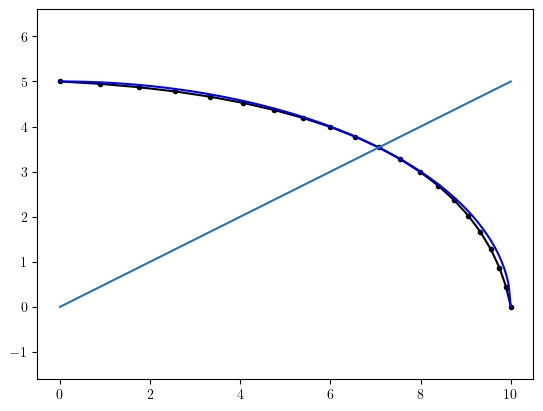

In [289]:
def quad_trajectory(N, state_0, state_f, p):
    """ Generate a quadratic trajectory for 
    given x values based on p-norm approximation"""

    x0, y0, t0 = state_0
    xf, yf, tf = state_f

    eqn = lambda x : ((1**p - (x/xf)**p)**(1/p))*y0 - ((y0/xf)*x)
    alpha = sc.optimize.fsolve(eqn, xf/2)[0]

    A = np.zeros((6,6))
    poly_basis = lambda t_i :[1, t_i, t_i**2]

    A[0,0:3] = poly_basis(t0); A[1,3:] = poly_basis(t0);
    A[2,0:3] = poly_basis(tf); A[3,3:] = poly_basis(tf);
    A[4,0:3] = poly_basis(tf/2); A[5,3:] = poly_basis(tf/2);

    q = np.array([x0, y0, xf, yf, alpha, ((y0/xf)*alpha)])
    coeffs = np.linalg.solve(A, q)
    coeffs_x = coeffs[0:3]
    coeffs_y = coeffs[3:]

    # obtain the trajectory in terms of time
    traj = np.zeros((N, 2))
    t = np.linspace(t0, tf, N)
    for i in range(len(t)):
        x_t = np.dot(coeffs_x, poly_basis(t[i]))
        y_t = np.dot(coeffs_y, poly_basis(t[i]))

        traj[i,:] = [x_t, y_t]

    # # parameterize the trajectory by length (only works when p = 1 rip)
    # t = sp.symbols('t', real = True, positive = True)
    # s = sp.symbols('s', real = True, positive = True)
    # s_t = sp.integrate(sp.sqrt( (coeffs[1] + coeffs[2]*(t))**2 + (coeffs[4] + coeffs[5]*(t))**2), t)
    # tot_length = float(s_t.subs(t, tf)) - float(s_t.subs(t, t0))
    # print(tot_length)

    # s_t = sp.series(s_t, t, x0=0, n=4).removeO()
    # eqn = sp.Eq(s, s_t)
    # # solve for t
    # t_s = sp.solve(eqn, t)[0]
    # # lambdify
    # t_s = sp.lambdify(s, t_s)

    # # generate the trajectory
    # # print(tot_length)
    # s_array = np.linspace(0, tot_length, N)
    # traj = np.zeros((N, 2))
    # for i in range(N):
    #     t_i = t_s(s_array[i])
    #     x_t = np.dot(coeffs_x, poly_basis(t_i))
    #     y_t = np.dot(coeffs_y, poly_basis(t_i))
    #     traj[i,:] = [x_t, y_t]

    return coeffs, traj

x0 = 0
y0 = 5
t0 = 0
xf = 10
yf = 0
tf = 10
t = np.linspace(t0, tf, 100)
x_list = np.linspace(x0, xf, 201)

state_0 = [x0, y0, t0]
state_f = [xf, yf, tf]
fig = plt.figure(dpi=100)
# p_list = [1, 1.2, 1.5, 2, 3, 5, 10, 25]
p_list = [2]

# p_list = [1]
N = 21

for p in p_list:
    coeffs, traj = quad_trajectory(N, state_0, state_f, p)
    plt.plot(traj[:,0], traj[:,1], '.-', color='black')
    y = p_norm_trajectory(x_list, p, xf, y0, 1)
    # y_der = p_norm_derivative(x, p, a, b, c)
    plt.plot(x_list, y, color='blue')
    # plt.plot(x, y_der, color='red')
    # plt.plot(np.abs(x-a), np.abs(y-b), color='black')

# equal axis
plt.plot([0,xf], [0, y0])
plt.axis('equal');

In [281]:
t = sp.symbols('t', complex = False)
s = sp.symbols('s',  complex = False)
s_t = sp.integrate(sp.sqrt( (coeffs[1] + coeffs[2]*(t))**2 + (coeffs[4] + coeffs[5]*(t))**2), t)
print(s_t)
tot_length = float(s_t.subs(t, tf)) - float(s_t.subs(t, t0))
print(tot_length)
eqn = sp.Eq(s, s_t)

f = sp.Function("f")

s_t = sp.series(s_t, t, x0=0, n=4).removeO()
eqn = sp.Eq(s, s_t)
t_s = sp.solve(eqn, t, )[0]
# # lambdify
# t_s = sp.lambdify(s, t_s)

# s_array = np.linspace(0, tot_length, N)
# traj = np.zeros((N, 2))
# for i in range(N):
#     t_i = t_s(s_array[i])
#     x_t = np.dot(coeffs_x, poly_basis(t_i))
#     y_t = np.dot(coeffs_y, poly_basis(t_i))
#     traj[i,:] = [x_t, y_t]

9.14374545873918*(0.5*t - 1.05712620670148)*sqrt(0.213419310788425*t**2 - 0.902444585802451*t + 1) + 0.455255993510382*asinh(2.1539105243401*t - 4.5539105243401)
7.103702058855926


In [282]:
t_s

-43.6896479541545*(-0.5 - 0.866025403784439*I)*(-0.000400727716564221*s + ((-0.000400727716564221*s - 1)**2 - 0.999698708184371)**0.5 - 1)**(1/3) + 45.9598326367158 - 43.6852597356282*(-0.5 + 0.866025403784439*I)/(-0.000400727716564221*s + ((-0.000400727716564221*s - 1)**2 - 0.999698708184371)**0.5 - 1)**(1/3)

In [284]:
t_s = sp.lambdify(s, t_s)

In [285]:
t_s(1)

<lambdifygenerated-29>:2: RuntimeWarning: invalid value encountered in scalar power
  return -43.6896479541545*(-0.5 - 0.866025403784439*1j)*(-0.000400727716564221*s + sqrt((-0.000400727716564221*s - 1)**2 - 0.999698708184371) - 1)**(1/3) + 45.9598326367158 - 43.6852597356282*(-0.5 + 0.866025403784439*1j)/(-0.000400727716564221*s + sqrt((-0.000400727716564221*s - 1)**2 - 0.999698708184371) - 1)**(1/3)


(nan+nanj)